# 9. 행 축소와 LU 분해

## 행 연산을 분해로 기록하기

- **배울 것**: 행렬 방정식의 곱셈 방향, RREF, 피벗과 LU 분해.
- $AX=B$에서 A를 없애려면 양변의 **왼쪽**에 $A^{-1}$를 곱합니다. 오른쪽에 곱하면 순서가 달라집니다.

$$
AX=B\Rightarrow X=A^{-1}B
$$

## RREF는 연립방정식을 읽기 쉬운 모양으로 바꾼다

- 허용되는 행 연산은 행 교환, 0이 아닌 수를 곱하기, 다른 행의 배수를 더하기입니다. 해집합이 보존됩니다.
- 피벗 열은 독립적인 제약을 표시하고, 비피벗 변수는 자유변수가 될 수 있습니다.
- $x+y=4$, $-x/2+y=2$의 확대행렬을 줄이면 $x=4/3,y=8/3$이 나옵니다.
- SymPy에서 정확한 유리수 연산을 원하면 `sym.Rational(1,2)`를 사용합니다. Python의 `1/2`는 부동소수점입니다.

## LU는 소거 과정을 재사용한다

$$
A=PLU,\qquad P^TA=LU
$$

- 이 글은 **SciPy의 규약**을 사용합니다. P는 행 교환, L은 단위 하삼각, U는 상삼각 행렬입니다.
- $Ax=b$를 풀 때 먼저 $Lz=P^Tb$, 다음으로 $Ux=z$를 풉니다. 앞에서부터 또는 뒤에서부터 한 변수씩 계산할 수 있습니다.
- 같은 A에 대해 여러 b를 풀 때 분해 결과를 재사용할 수 있습니다.

$$
\det(A)=\det(P)\prod_i u_{ii},\qquad
A^{-1}=U^{-1}L^{-1}P^T
$$

- L의 대각선은 1이므로 행렬식에 추가 배율을 주지 않습니다. 행 교환의 부호는 P에 담겨 있습니다.
- 직사각형 행렬에서도 LU 분해가 가능하지만 일반 역행렬이나 행렬식은 정사각형에 대해 다룹니다.
- **주의**: P를 무시하면 대부분의 행렬에서 재구성이 틀립니다. `A-P@L@U`의 노름을 확인하세요.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch09'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260934)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260934)

재현용 난수 시드: 20260934


### 코드 09-01

- 원본: `original_py/LA4DS_ch09.py` 1–18행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# sympy library for RREF
import sympy as sym

# scipy for LU
import scipy.linalg


# used to create non-regular subplots
import matplotlib.gridspec as gridspec


# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 행렬 방정식

### 코드 09-02

- 원본: `original_py/LA4DS_ch09.py` 22–42행.

In [3]:
# generate some matrices
A = np.random.randn(4,4)
B = np.random.randn(4,4)

# solve for X
# 1) inv(A)@A@X = inv(A)@B
# 2) inv(A)@A@X = B@inv(A)

X1 = np.linalg.inv(A) @ B
X2 = B @ np.linalg.inv(A)

# residual (should be zeros matrix)
res1 = A@X1 - B
res2 = A@X2 - B

# which is correct?
print('res1:'), print(' ')
print( np.round(res1,10) ), print(' ')

print('res2:'), print(' ')
print( np.round(res2,10) )

res1:
 
[[ 0.  0.  0.  0.]
 [ 0. -0. -0. -0.]
 [ 0.  0.  0.  0.]
 [-0. -0.  0.  0.]]
 
res2:
 
[[ 3.035313 -0.207301  2.625162  0.922837]
 [ 0.975571 -2.424384 -1.330085 -0.921193]
 [-4.538595 -2.096134 -2.529029  1.380961]
 [ 1.707463  0.394935  0.212459  1.918101]]


### 기약 행 사다리꼴

### 코드 09-03

- 원본: `original_py/LA4DS_ch09.py` 47–55행.

In [4]:
# the augmented matrix
M = np.array([ [1,1,4],[-1/2,1,2] ])

# converted into a sympy matrix
symMat = sym.Matrix(M)
print(symMat)

# RREF
symMat.rref()[0] # just the first output to get the RREF matrix (the second output is the indices of the pivots per row)

Matrix([[1.00000000000000, 1.00000000000000, 4.00000000000000], [-0.500000000000000, 1.00000000000000, 2.00000000000000]])
Out[4]: 
Matrix([
[1, 0, 1.33333333333333],
[0, 1, 2.66666666666667]])


### LU 분해

### 코드 09-04

- 원본: `original_py/LA4DS_ch09.py` 59–75행.

In [5]:
# simple example with integers

# a matrix
A = np.array([ [2,2,4], [1,0,3], [2,1,2] ])

# its LU decomposition via scipy (please ignore the first output for now)
_,L,U = scipy.linalg.lu(A)

# print them out
print('L: ')
print(L), print(' ')

print('U: ')
print(U), print(' ')

print('A - LU: ')
print(A - L@U) # should be zeros

L: 
[[1.  0.  0. ]
 [0.5 1.  0. ]
 [1.  1.  1. ]]
 
U: 
[[ 2.  2.  4.]
 [ 0. -1.  1.]
 [ 0.  0. -3.]]
 
A - LU: 
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


### 코드 09-05

- 원본: `original_py/LA4DS_ch09.py` 77–113행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: SciPy의 A=PLU 규약에 맞춰 순열행렬 그림을 P로 수정했습니다.
- **보완**: 순열행렬 그림의 표기를 수정했습니다.

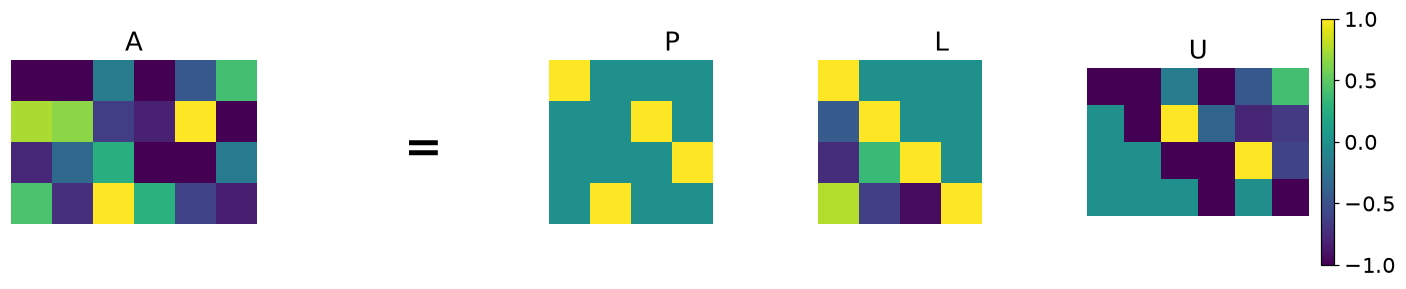

In [6]:
# matrix sizes
m = 4
n = 6

A = np.random.randn(m,n)

P,L,U = scipy.linalg.lu(A)

# show the matrices
fig,axs = plt.subplots(1,5,figsize=(13,4))

axs[0].imshow(A,vmin=-1,vmax=1)
axs[0].set_title('A')

axs[1].imshow(np.ones((m,n)),cmap='gray',vmin=-1,vmax=1)
axs[1].text(n/2,m/2,'=',ha='center',fontsize=30,fontweight='bold')
# axs[1].axis('off')

axs[2].imshow(P,vmin=-1,vmax=1)
axs[2].set_title('P')

axs[3].imshow(L,vmin=-1,vmax=1)
axs[3].set_title('L')

h = axs[4].imshow(U,vmin=-1,vmax=1)
axs[4].set_title('U')

for a in axs:
  a.axis('off')
  a.set_xlim([-.5,n-.5])
  a.set_ylim([m-.5,-.5])


fig.colorbar(h,ax=axs[-1],fraction=.05)
plt.tight_layout()
plt.savefig(ASSET / 'Figure_09_01.png',dpi=140)
plt.show()

## 연습문제 1 · LU 실행 시간 측정

- **목표**: 반복 분해의 계산 비용을 측정합니다.
- **풀이 순서**: 100×100 난수행렬을 1000번 만들고 SciPy LU를 수행해 총 시간을 출력합니다.
- **결과 해석**: 시간에는 난수 생성도 포함됩니다. 환경마다 달라지는 측정값이며 고정된 성능 수치가 아닙니다. 정의되지 않은 spla 호출은 수정했습니다.

### 코드 09-06

- 원본: `original_py/LA4DS_ch09.py` 117–131행.
- **보완**: 정의되지 않은 spla 이름을 scipy.linalg로 수정했습니다.

In [7]:
# Time-test!

import time

# start the timer
tic = time.time()

# run the test
for i in range(1000):
  A = np.random.randn(100,100)
  P,L,U = scipy.linalg.lu(A)

# stop the timer
toc = time.time() - tic
toc # print the result in seconds

Out[7]: 0.2132244110107422


## 연습문제 2 · 낮은 랭크의 LU

- **목표**: 랭크 부족이 U에서 어떻게 드러나는지 관찰합니다.
- **풀이 순서**: 6×3과 3×8 난수행렬을 곱해 rank 3의 A를 만들고 LU를 분해합니다.
- **결과 해석**: A와 U의 수치 랭크는 3입니다. L은 모든 열이 독립일 수 있습니다. 검은 색 행이 보인다고 정확한 0인지 단정하지 말고 수치도 확인합니다.

### 코드 09-07

- 원본: `original_py/LA4DS_ch09.py` 135–162행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

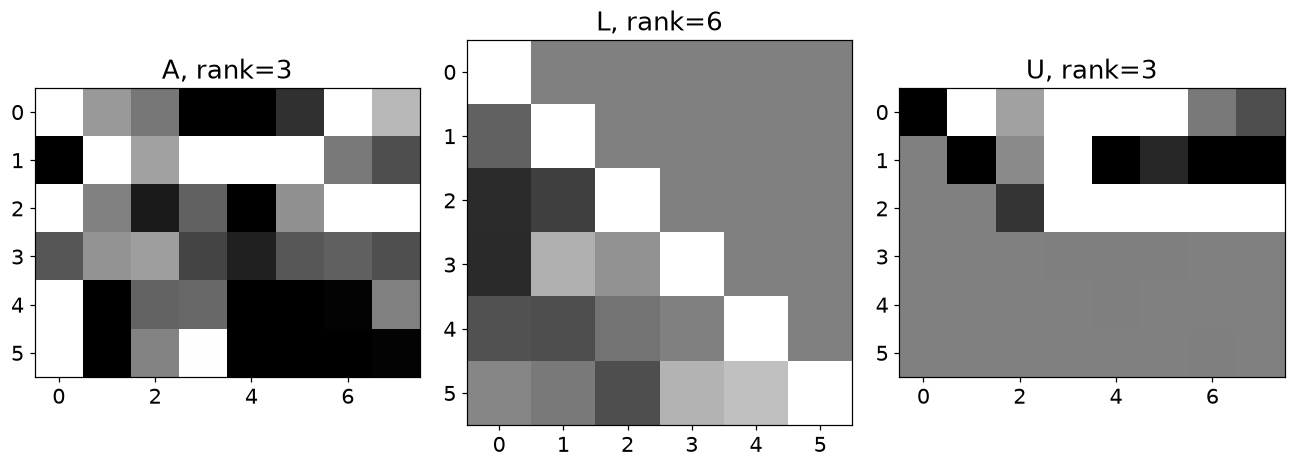

In [8]:
# make a reduced-rank random matrix

# sizes and rank
M = 6
N = 8
r = 3

# create the matrix
A = np.random.randn(M,r) @ np.random.randn(r,N)

# LU
P,L,U = scipy.linalg.lu(A)

# and plot
_,axs = plt.subplots(1,3,figsize=(12,7))

axs[0].imshow(A,vmin=-1,vmax=1,cmap='gray')
axs[0].set_title(f'A, rank={np.linalg.matrix_rank(A)}')

axs[1].imshow(L,vmin=-1,vmax=1,cmap='gray')
axs[1].set_title(f'L, rank={np.linalg.matrix_rank(L)}')

axs[2].imshow(U,vmin=-1,vmax=1,cmap='gray')
axs[2].set_title(f'U, rank={np.linalg.matrix_rank(U)}')

plt.tight_layout()
plt.savefig(ASSET / 'Figure_09_02.png',dpi=140)
plt.show()

### 코드 09-08

- 원본: `original_py/LA4DS_ch09.py` 164–164행.

In [9]:
np.round(L,2)

Out[9]: 
array([[ 1.  ,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [-0.23,  1.  ,  0.  ,  0.  ,  0.  ,  0.  ],
       [-0.66, -0.5 ,  1.  ,  0.  ,  0.  ,  0.  ],
       [-0.67,  0.37,  0.14,  1.  ,  0.  ,  0.  ],
       [-0.35, -0.39, -0.1 , -0.  ,  1.  ,  0.  ],
       [ 0.05, -0.05, -0.39,  0.4 ,  0.5 ,  1.  ]])


## 연습문제 3 · LU로 행렬식 구하기

- **목표**: U의 대각곱과 행 교환 부호를 연결합니다.
- **풀이 순서**: U 대각 원소 곱에 det(P)를 곱하고 np.linalg.det(A)와 비교합니다.
- **결과 해석**: 차이는 반올림 오차 정도입니다. det(P)를 빼먹으면 홀수 번 교환했을 때 부호가 반대가 됩니다.

### 코드 09-09

- 원본: `original_py/LA4DS_ch09.py` 168–183행.

In [10]:
# a matrix and its det
M = 6
A = np.random.randn(M,M)

# LU
P,L,U = scipy.linalg.lu(A)

# determinant as the product of the diagonals of U
detLU = np.prod( np.diag(U) ) * np.linalg.det(P)

# check against the det function
detNP = np.linalg.det(A)

# compare
print(detLU,detNP)
print(detLU-detNP)

55.593749230789065 55.593749230789044
2.1316282072803006e-14


## 연습문제 4 · LU로 역행렬 구성

- **목표**: 분해된 변환을 역순으로 되돌립니다.
- **풀이 순서**: $A=PLU$에서 $A^{-1}=U^{-1}L^{-1}P^T$를 만들고 A와 곱합니다.
- **결과 해석**: 항등행렬이 나옵니다. 실제 선형계 풀이는 이 역행렬들을 만들기보다 전진·후진 대입이 효율적입니다.

### 코드 09-10

- 원본: `original_py/LA4DS_ch09.py` 187–200행.

In [11]:
# matrix sizes
m = 4
A = np.random.randn(m,m)

# LU decomposition
P,L,U = scipy.linalg.lu(A)

# inverse
invViaLU = np.linalg.inv(U) @ np.linalg.inv(L) @ P.T

# "regular" inverse
invViaInv = np.linalg.inv(A)

np.round( A@invViaLU ,10)

Out[11]: 
array([[ 1., -0., -0.,  0.],
       [ 0.,  1.,  0., -0.],
       [-0.,  0.,  1., -0.],
       [ 0., -0., -0.,  1.]])


## 연습문제 5 · Gram 행렬에서 P가 사라지는 이유

- **목표**: $A^TA=U^TL^TLU$를 유도합니다.
- **풀이 순서**: PLU를 양쪽에 대입하고 가운데 $P^TP=I$를 소거합니다. 직접 계산과 비교합니다.
- **결과 해석**: 차이는 0 근처입니다. 순열이 관측 행을 재배열할 뿐 열 사이 내적을 바꾸지 않기 때문입니다.

### 코드 09-11

- 원본: `original_py/LA4DS_ch09.py` 204–220행.

In [12]:
# The reason is that writing out the equation leads to PtP in the middle, which is the identity matrix. 
# Conceptually, it means that any row swaps are undone when multiplying by the transpose.

# create a matrix
A = np.random.randn(4,4)

# LUP
P,L,U = scipy.linalg.lu(A)

# compute AtA via LU
AtA_lu = U.T @ L.T @ L @ U

# direct computation
AtA_direct = A.T @ A

# compare to direct computation
np.round( AtA_lu - AtA_direct ,10)

Out[12]: 
array([[ 0.,  0.,  0.,  0.],
       [-0.,  0.,  0.,  0.],
       [-0.,  0., -0.,  0.],
       [ 0.,  0.,  0., -0.]])


## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [13]:
from scipy.linalg import lu
_A=np.array([[0.,2.],[3.,4.]])
_P,_L,_U=lu(_A)
print('P:\n',_P,'\nL:\n',_L,'\nU:\n',_U)
print('행렬식:',np.linalg.det(_P)*np.prod(np.diag(_U)))
assert np.allclose(_A,_P@_L@_U)
assert np.allclose(np.linalg.det(_A),np.linalg.det(_P)*np.prod(np.diag(_U)))


P:
 [[0. 1.]
 [1. 0.]] 
L:
 [[1. 0.]
 [0. 1.]] 
U:
 [[3. 4.]
 [0. 2.]]
행렬식: -6.0
